# Regressão Linear: Airbnb Lisboa

Projeto Prático 1: Machine Learning

Gradient descent implementado do zero, com regularização L2, comparação
raw price vs log price, features polinomiais/interações, k-fold, e os
estudos de outliers e missing values pedidos no enunciado.

**Pré-requisito:** correr o `data_preparation.ipynb` até ao fim (incluindo
a secção 14), que gera as pastas `data_prepared/<missing>_<outlier>/`
usadas aqui.

## 0. Configuração

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
SEED = 42

## 1. Função para carregar uma pasta preparada

In [28]:
def carregar_pasta(pasta):
    X_train = pd.read_csv(f"{pasta}/X_train.csv")
    X_val = pd.read_csv(f"{pasta}/X_val.csv")
    X_test = pd.read_csv(f"{pasta}/X_test.csv")
    y_train = pd.read_csv(f"{pasta}/y_train.csv")
    y_val = pd.read_csv(f"{pasta}/y_val.csv")
    y_test = pd.read_csv(f"{pasta}/y_test.csv")
    return {
        "X_train": X_train.values.astype(float), "y_train": y_train["price"].values.astype(float),
        "y_train_log": y_train["log_price"].values.astype(float), "y_train_clf": y_train["high_price"].values.astype(int),
        "X_val": X_val.values.astype(float), "y_val": y_val["price"].values.astype(float),
        "y_val_log": y_val["log_price"].values.astype(float), "y_val_clf": y_val["high_price"].values.astype(int),
        "X_test": X_test.values.astype(float), "y_test": y_test["price"].values.astype(float),
        "y_test_log": y_test["log_price"].values.astype(float), "y_test_clf": y_test["high_price"].values.astype(int),
        "feature_cols": X_train.columns.tolist(),
        "val_df_raw": X_val,
        "test_df_raw": X_test,
    }

## 2. Gradient descent (implementação do zero)

Regressão linear com termo de bias, mini-batch gradient descent, e
regularização L2 opcional (o bias nunca é penalizado).

In [29]:
def adicionar_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def prever(X_com_bias, w):
    return X_com_bias @ w

def custo_mse(X_com_bias, y, w, l2=0.0):
    n = len(y)
    erro = prever(X_com_bias, w) - y
    mse = (erro ** 2).mean()
    penalidade = l2 * np.sum(w[1:] ** 2) / n   # bias (w[0]) nao e penalizado
    return mse + penalidade

def gradiente(X_com_bias, y, w, l2=0.0):
    n = len(y)
    erro = prever(X_com_bias, w) - y
    grad = (X_com_bias.T @ erro) / n
    grad[1:] += (2 * l2 / n) * w[1:]
    return grad

def treinar_gradient_descent(X, y, lr=0.01, epochs=500, l2=0.0, batch_size=None, seed=SEED):
    rng = np.random.default_rng(seed)
    X_bias = adicionar_bias(X)
    n, d = X_bias.shape
    w = np.zeros(d)
    historico_custo = []

    for epoch in range(epochs):
        if batch_size is None:
            grad = gradiente(X_bias, y, w, l2)
            w = w - lr * grad
        else:
            indices = rng.permutation(n)
            for inicio in range(0, n, batch_size):
                idx = indices[inicio:inicio + batch_size]
                grad = gradiente(X_bias[idx], y[idx], w, l2)
                w = w - lr * grad
        historico_custo.append(custo_mse(X_bias, y, w, l2))

    return w, historico_custo

In [30]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def avaliar(w, X, y):
    y_pred = prever(adicionar_bias(X), w)
    return {"MAE": mae(y, y_pred), "RMSE": rmse(y, y_pred), "R2": r2(y, y_pred)}

## 3. Estudo cruzado de pré-processamento (outlier × missing)

Treina o mesmo modelo nas 6 combinações geradas pelo `data_preparation.ipynb`
e compara, antes de qualquer outra experiência. Os resultados desta secção
são usados na secção seguinte para escolher, de forma fundamentada, a
combinação de pré-processamento usada como referência no resto do notebook.

Nesta fase os modelos são treinados sem regularização L2 (lambda=0), já que
o valor ótimo de lambda só é determinado mais à frente (secção 9),
especificamente para a combinação escolhida.

In [31]:
resultados_cruzados = []
for missing_strategy in ["simple", "grouped"]:
    for outlier_strategy in ["none", "cap", "drop"]:
        print(f"a treinar {missing_strategy}_{outlier_strategy}...")
        d = carregar_pasta(f"data_prepared/{missing_strategy}_{outlier_strategy}")
        # 200 epochs chega para comparar as combinacoes; o modelo final
        # (secção 11) e treinado com mais epochs so na pasta escolhida
        w, _ = treinar_gradient_descent(d["X_train"], d["y_train"], lr=0.05, epochs=200, l2=0.0, batch_size=256)
        metrica = avaliar(w, d["X_val"], d["y_val"])
        resultados_cruzados.append({
            "missing_strategy": missing_strategy,
            "outlier_strategy": outlier_strategy,
            **metrica
        })

df_cruzado = pd.DataFrame(resultados_cruzados)
df_cruzado

a treinar simple_none...
a treinar simple_cap...
a treinar simple_drop...
a treinar grouped_none...
a treinar grouped_cap...
a treinar grouped_drop...


,missing_strategy,outlier_strategy,MAE,RMSE,R2
0,simple,none,93.734861,432.634076,0.097578
1,simple,cap,42.841439,58.818335,0.580164
2,simple,drop,81.167117,444.667486,0.046679
3,grouped,none,93.872464,432.793850,0.096911
4,grouped,cap,42.853687,58.771396,0.580833
5,grouped,drop,81.213025,444.714187,0.046479


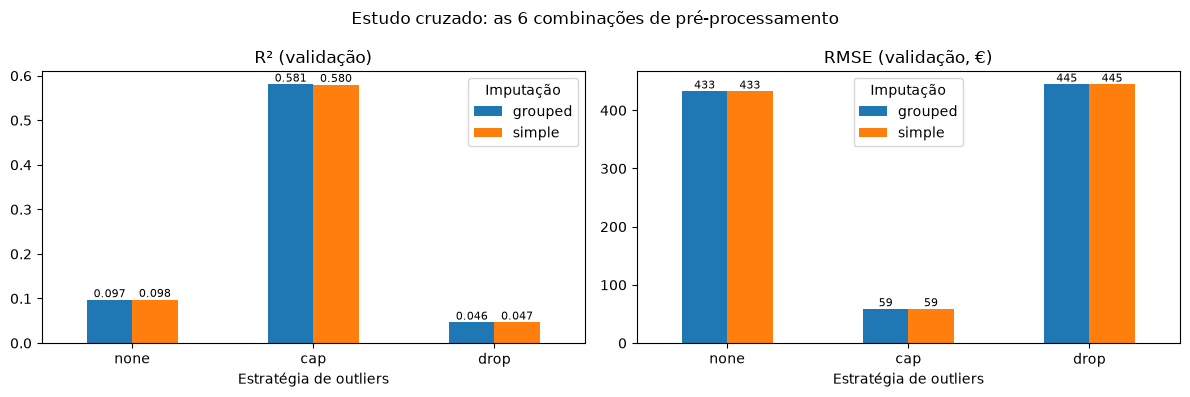

In [32]:
ordem = ["none", "cap", "drop"]
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for eixo, metrica, titulo in zip(eixos, ["R2", "RMSE"], ["R² (validação)", "RMSE (validação, €)"]):
    tabela = df_cruzado.pivot(index="outlier_strategy", columns="missing_strategy", values=metrica).loc[ordem]
    tabela.plot(kind="bar", ax=eixo, rot=0)
    for cont in eixo.containers:
        eixo.bar_label(cont, fmt="%.3f" if metrica == "R2" else "%.0f", fontsize=8)
    eixo.set_xlabel("Estratégia de outliers")
    eixo.set_title(titulo)
    eixo.legend(title="Imputação")
plt.suptitle("Estudo cruzado: as 6 combinações de pré-processamento")
plt.tight_layout()
plt.show()

### Nota de leitura

A tabela anterior apresenta, para cada uma das seis combinações possíveis entre a estratégia de imputação de valores em falta e a estratégia de tratamento de outliers, as métricas de desempenho obtidas no conjunto de validação. As duas subsecções seguintes isolam o efeito de cada uma destas dimensões através do cálculo de médias marginais.

### 3.1. Outlier study (média sobre as 2 estratégias de missing)

In [33]:
df_outlier_study = df_cruzado.groupby("outlier_strategy")[["MAE", "RMSE", "R2"]].mean().round(3)
df_outlier_study

,MAE,RMSE,R2
outlier_strategy,,,
cap,42.848,58.795,0.580
drop,81.190,444.691,0.047
none,93.804,432.714,0.097


### Discussão

- **Capping:** R²=**0,580** e RMSE=**58,8 €**. **Drop** e **none:** R²=**0,047** e **0,097**, RMSE≈**445 €** e **433 €**.
- **Cuidado com a comparação:** no capping, o preço de validação e de teste também é limitado ao máximo do treino, pelo que as métricas se referem a um alvo sem extremos. Em drop e none os alojamentos de luxo (ex.: `Entire villa`) mantêm-se e, como o RMSE penaliza quadraticamente, dominam o erro.
- **Drop vs none:** drop tem menor MAE (**81,2** contra **93,8 €**) mas maior RMSE (**444,7** contra **432,7 €**). Sem extremos no treino, o modelo ajusta-se melhor aos casos típicos, mas não acompanha os extremos da validação.
- **Conclusão:** o capping é adotado como referência por dar uma avaliação estável. Afirmar a sua superioridade absoluta exigiria avaliar todos os modelos sobre o mesmo alvo (preços originais).

### 3.2. Missing-value study (média sobre as 3 estratégias de outlier)

In [34]:
df_missing_study = df_cruzado.groupby("missing_strategy")[["MAE", "RMSE", "R2"]].mean().round(3)
df_missing_study

,MAE,RMSE,R2
missing_strategy,,,
grouped,72.646,312.093,0.241
simple,72.581,312.040,0.241


### Discussão

- **Médias marginais:** R²=**0,241** nas duas políticas, mas diluído pelas estratégias `drop` e `none`.
- **Comparação justa (só com capping):** `simple_cap` R²=**0,5802** e `grouped_cap` R²=**0,5808**, diferença de **0,0007**. MAE e RMSE também praticamente iguais.
- **Conclusão:** a imputação tem impacto praticamente nulo neste dataset. Possível razão: em variáveis discretas como `bedrooms` e `bathrooms`, a mediana do grupo difere pouco da global.
- **Quando cada política é defensável:**
  - **Simples:** robusta quando há grupos com poucas observações.
  - **Agrupada:** preferível se existe heterogeneidade real entre bairros e tipos de alojamento; recorre à mediana global quando o grupo é pequeno.

## 4. Escolha da pasta principal

Com base no estudo cruzado da secção anterior, seleciona-se automaticamente,
como `PASTA_PRINCIPAL`, a combinação de estratégias de pré-processamento com
o maior R² obtido no conjunto de validação. Esta escolha deixa de ser
arbitrária e passa a ser inteiramente determinada pelos resultados já
apresentados. A combinação selecionada é utilizada como referência em todas
as secções seguintes (regressão com o preço bruto, log-price, termos
polinomiais e de interação, regularização L2, k-fold, modelo final, análise
de resíduos, erro por grupo e interpretação dos coeficientes).

In [35]:
melhor_combo = df_cruzado.loc[df_cruzado["R2"].idxmax()]
PASTA_PRINCIPAL = f"data_prepared/{melhor_combo['missing_strategy']}_{melhor_combo['outlier_strategy']}"

print(f"Melhor combinação: missing_strategy='{melhor_combo['missing_strategy']}', "
      f"outlier_strategy='{melhor_combo['outlier_strategy']}' (R²={melhor_combo['R2']:.3f} na validação)")
print(f"Pasta principal definida como: {PASTA_PRINCIPAL}")

dados = carregar_pasta(PASTA_PRINCIPAL)
print("\nX_train:", dados["X_train"].shape)
print("X_val:  ", dados["X_val"].shape)
print("X_test: ", dados["X_test"].shape)
print("Features:", dados["feature_cols"])

Melhor combinação: missing_strategy='grouped', outlier_strategy='cap' (R²=0.581 na validação)
Pasta principal definida como: data_prepared/grouped_cap

X_train: (15846, 43)
X_val:   (3395, 43)
X_test:  (3395, 43)
Features: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'availability_365', 'host_is_superhost', 'has_reviews', 'n_amenities', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'property_type_Entire condo', 'property_type_Entire home', 'property_type_Entire rental unit', 'property_type_Entire serviced apartment', 'property_type_Entire villa', 'property_type_Other', 'property_type_Private room in bed and breakfast', 'property_type_Private room in guesthouse', 'property_type_Private room in home', 'property_type_Private room in rental unit', 'property_type_Room in hotel', 'neighbourhood_cleansed_Areeiro', 'neighbourhood_cleansed_Arroios', 

### Resultado da seleção

- **Combinação escolhida:** `grouped_cap`, com **R²=0,581** na validação.
- **Face a `simple_cap`:** vantagem de apenas 0,0007, na prática um empate; o critério (maior R²) só desempata.
- **Decisão com peso real:** o tratamento de outliers (capping **> 0,58**; as restantes **< 0,10**), com a ressalva da secção 3.1.

## 5. Baseline: prever `price` (bruto)

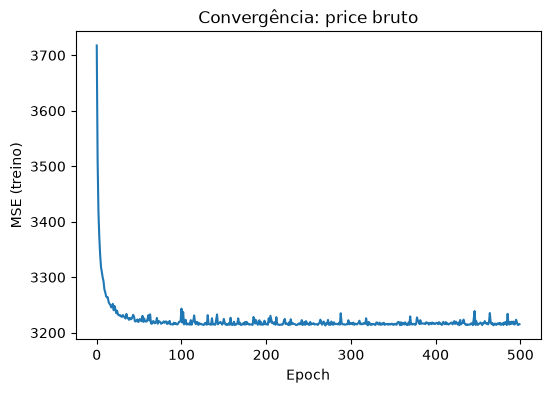

Treino: {'MAE': np.float64(41.72334287022081), 'RMSE': np.float64(56.70361500975201), 'R2': np.float64(0.605165649252076)}
Val:    {'MAE': np.float64(42.76837617637729), 'RMSE': np.float64(58.79836668184375), 'R2': np.float64(0.5804485534141806)}


In [36]:
w_base, custo_base = treinar_gradient_descent(
    dados["X_train"], dados["y_train"], lr=0.05, epochs=500, batch_size=256
)

plt.figure(figsize=(6, 4))
plt.plot(custo_base)
plt.xlabel("Epoch")
plt.ylabel("MSE (treino)")
plt.title("Convergência: price bruto")
plt.show()

print("Treino:", avaliar(w_base, dados["X_train"], dados["y_train"]))
print("Val:   ", avaliar(w_base, dados["X_val"], dados["y_val"]))

### Discussão

- **Resultado (validação):** R²=**0,580**, MAE=**42,8 €**, RMSE=**58,8 €**; cerca de **58%** da variância do preço explicada.
- **Contexto:** o preço depende de fatores ausentes (localização exata, fotografias, reputação, sazonalidade). Um R²≈0,6 é razoável para um modelo linear simples.
- **Sobreajuste:** treino **0,605** contra validação **0,580** (diferença de 0,025), logo sem sobreajuste relevante.
- **Nota:** as métricas referem-se a preços já limitados pela winsorização (secção 3).

## 6. `log_price` vs `price` bruto

Treina o mesmo modelo a prever `log(1 + price)`, depois desfaz a
transformação (`expm1`) para comparar as métricas na escala original do preço.

In [37]:
w_log, custo_log = treinar_gradient_descent(
    dados["X_train"], dados["y_train_log"], lr=0.05, epochs=500, batch_size=256
)

def avaliar_log(w, X, y_price_real):
    y_pred_log = prever(adicionar_bias(X), w)
    y_pred_price = np.expm1(y_pred_log)
    return {"MAE": mae(y_price_real, y_pred_price), "RMSE": rmse(y_price_real, y_pred_price),
            "R2": r2(y_price_real, y_pred_price)}

print("=== price bruto ===")
print("Treino:", avaliar(w_base, dados["X_train"], dados["y_train"]))
print("Val:   ", avaliar(w_base, dados["X_val"], dados["y_val"]))

print("\n=== log_price (convertido de volta) ===")
print("Treino:", avaliar_log(w_log, dados["X_train"], dados["y_train"]))
print("Val:   ", avaliar_log(w_log, dados["X_val"], dados["y_val"]))

=== price bruto ===
Treino: {'MAE': np.float64(41.72334287022081), 'RMSE': np.float64(56.70361500975201), 'R2': np.float64(0.605165649252076)}
Val:    {'MAE': np.float64(42.76837617637729), 'RMSE': np.float64(58.79836668184375), 'R2': np.float64(0.5804485534141806)}

=== log_price (convertido de volta) ===
Treino: {'MAE': np.float64(41.04929476216459), 'RMSE': np.float64(59.766408589669176), 'R2': np.float64(0.5613604836470226)}
Val:    {'MAE': np.float64(41.30079902763912), 'RMSE': np.float64(60.433713240275864), 'R2': np.float64(0.556786217270715)}


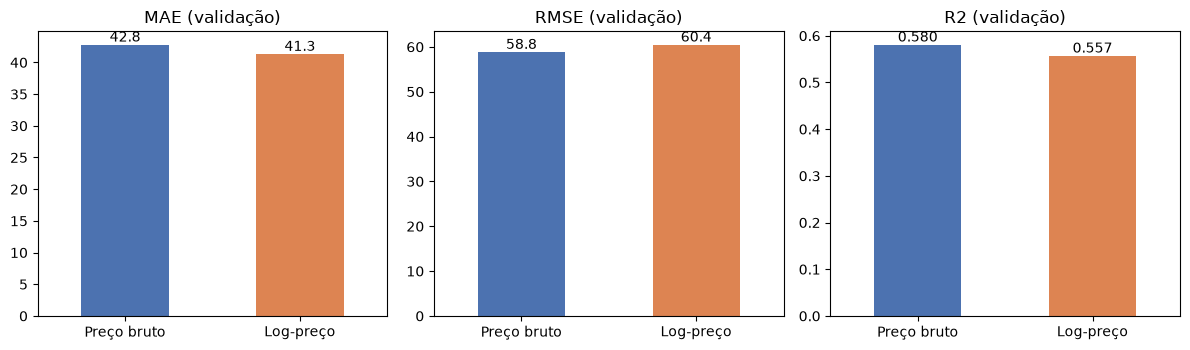

In [38]:
metricas_log = pd.DataFrame({
    "Preço bruto": avaliar(w_base, dados["X_val"], dados["y_val"]),
    "Log-preço": avaliar_log(w_log, dados["X_val"], dados["y_val"]),
}).T.astype(float)

fig, eixos = plt.subplots(1, 3, figsize=(12, 3.6))
for eixo, metrica in zip(eixos, ["MAE", "RMSE", "R2"]):
    metricas_log[metrica].plot(kind="bar", ax=eixo, rot=0, color=["#4C72B0", "#DD8452"])
    eixo.bar_label(eixo.containers[0], fmt="%.3f" if metrica == "R2" else "%.1f")
    eixo.set_title(metrica + " (validação)")
plt.tight_layout()
plt.show()

### Discussão

- **Resultado:** o MAE desce (**41,3** contra 42,8 €), mas o RMSE sobe (**60,4** contra 58,8 €) e o R² desce (**0,557** contra 0,580).
- **Porquê:** o MAE pondera os erros de forma linear; o RMSE e o R² penalizam os erros grandes (preços altos). O logaritmo minimiza erros relativos, o que favorece preços baixos e intermédios.
- **Pouco benefício aqui:** a winsorização já limita a cauda do preço; além disso, converter de volta com a exponencial subestima o preço esperado (enviesamento de retransformação).
- **Conclusão:** sem vantagem no critério principal (RMSE e R²), mantém-se o preço em bruto.

## 7. Features polinomiais (graus 2 e 3)

Acrescentam-se termos de grau superior a todas as variáveis numéricas não binárias, comparando o grau 2 (quadrado) e o grau 3 (quadrado e cubo) com o modelo linear (grau 1). As variáveis binárias ficam de fora, uma vez que 0 e 1 elevados a qualquer potência mantêm o valor.

Por estabilidade numérica do gradient descent, os valores são limitados a 4 desvios-padrão (clip) antes de serem elevados à potência e, depois de as colunas novas serem padronizadas, voltam a ser limitados ao mesmo intervalo. Estas salvaguardas aplicam-se apenas às colunas novas: as colunas originais mantêm os valores iniciais e não fazem parte do estudo de outliers da secção 3.

In [39]:
def adicionar_polinomiais(X, feature_cols, cols_alvo, grau=2, limite=4.0):
    """Acrescenta as potencias 2..grau de cada coluna indicada. O valor e
    limitado (clip) a +-limite desvios-padrao antes de ser elevado, como
    salvaguarda de estabilidade numerica: sem isto, um unico valor extremo
    elevado ao quadrado ou ao cubo faz o gradient descent divergir. O clip
    so afeta as colunas novas; as originais ficam inalteradas."""
    X_novo = X.copy()
    novos_nomes = list(feature_cols)
    for col in cols_alvo:
        idx = feature_cols.index(col)
        valor_limitado = np.clip(X[:, [idx]], -limite, limite)
        for p in range(2, grau + 1):
            X_novo = np.hstack([X_novo, valor_limitado ** p])
            novos_nomes.append(f"{col}^{p}")
    return X_novo, novos_nomes

def escalar_colunas_novas(X_train_novo, X_val_novo, n_colunas_originais, limite=4.0):
    """As colunas adicionadas (polinomiais/interacoes) tem escalas
    diferentes das restantes (ja escaladas na preparacao dos dados).
    Padronizam-se com as estatisticas do treino e limitam-se a +-limite
    desvios-padrao: depois de potencias elevadas, a variancia de uma coluna
    e dominada por poucos pontos extremos, que sem este limite voltam a
    ficar muito grandes e fazem o gradient descent divergir."""
    media = X_train_novo[:, n_colunas_originais:].mean(axis=0)
    desvio = X_train_novo[:, n_colunas_originais:].std(axis=0)
    desvio[desvio == 0] = 1.0
    X_train_novo = X_train_novo.copy()
    X_val_novo = X_val_novo.copy()
    novo_train = (X_train_novo[:, n_colunas_originais:] - media) / desvio
    novo_val = (X_val_novo[:, n_colunas_originais:] - media) / desvio
    X_train_novo[:, n_colunas_originais:] = np.clip(novo_train, -limite, limite)
    X_val_novo[:, n_colunas_originais:] = np.clip(novo_val, -limite, limite)
    return X_train_novo, X_val_novo

# todas as colunas nao binarias (as binarias nao ganham nada com potencias)
cols_para_polinomio = [
    col for j, col in enumerate(dados["feature_cols"])
    if np.unique(dados["X_train"][:, j]).size > 2
]
print("Colunas com termos polinomiais:", cols_para_polinomio)

resultados_poly = [{
    "grau": 1,
    "n_features": dados["X_train"].shape[1],
    **avaliar(w_base, dados["X_val"], dados["y_val"]),
}]

for grau in [2, 3]:
    X_train_poly, _ = adicionar_polinomiais(dados["X_train"], dados["feature_cols"], cols_para_polinomio, grau)
    X_val_poly, _ = adicionar_polinomiais(dados["X_val"], dados["feature_cols"], cols_para_polinomio, grau)
    X_train_poly, X_val_poly = escalar_colunas_novas(X_train_poly, X_val_poly, len(dados["feature_cols"]))

    w_poly, _ = treinar_gradient_descent(X_train_poly, dados["y_train"], lr=0.05, epochs=500, batch_size=256)
    resultados_poly.append({
        "grau": grau,
        "n_features": X_train_poly.shape[1],
        **avaliar(w_poly, X_val_poly, dados["y_val"]),
    })

df_poly = pd.DataFrame(resultados_poly)
df_poly

Colunas com termos polinomiais: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'availability_365', 'n_amenities']


,grau,n_features,MAE,RMSE,R2
0,1,43,42.768376,58.798367,0.580449
1,2,53,42.444669,58.093408,0.590449
2,3,63,42.075899,57.477325,0.599089


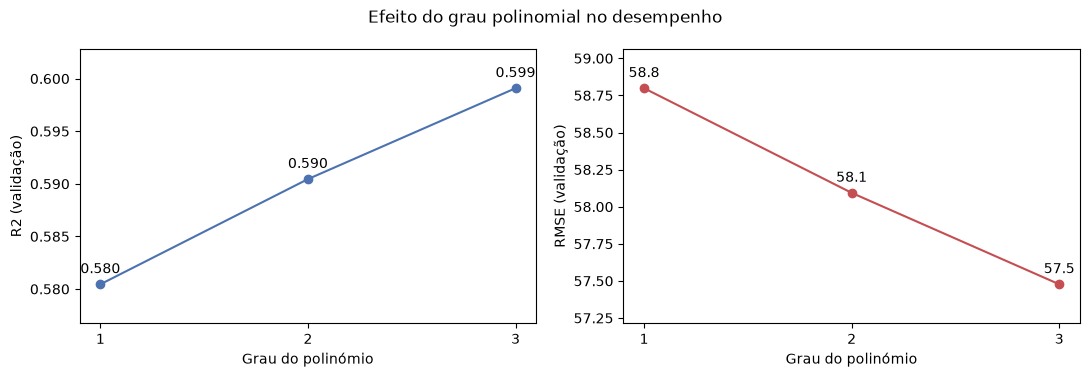

In [40]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 3.8))
for eixo, metrica, cor in zip(eixos, ["R2", "RMSE"], ["#4C72B0", "#C44E52"]):
    eixo.plot(df_poly["grau"], df_poly[metrica], marker="o", color=cor)
    for x, y in zip(df_poly["grau"], df_poly[metrica]):
        eixo.annotate(f"{y:.3f}" if metrica == "R2" else f"{y:.1f}", (x, y),
                      textcoords="offset points", xytext=(0, 8), ha="center")
    eixo.set_xticks(df_poly["grau"])
    eixo.set_xlabel("Grau do polinómio")
    eixo.set_ylabel(metrica + " (validação)")
    eixo.margins(y=0.2)
plt.suptitle("Efeito do grau polinomial no desempenho")
plt.tight_layout()
plt.show()

### Discussão

- **Resultado (validação):** R² **0,580 → 0,590 → 0,599** (graus 1, 2, 3); RMSE **58,8 → 58,1 → 57,5 €**; MAE **42,8 → 42,4 → 42,1 €**. Custo: de 43 para 63 variáveis.
- **Significância:** o ganho de 0,019 em R² equivale a cerca de **2,7 vezes** o desvio-padrão entre folds (0,007), pelo que provavelmente não é ruído (indicativo, sem teste formal).
- **Interpretação:** existe alguma não linearidade entre as variáveis numéricas e o preço. O ganho do grau 3 (0,009) é semelhante ao do grau 2 (0,010), logo ainda não estabilizou; graus superiores não foram testados por risco de sobreajuste e de instabilidade numérica.
- **Ressalvas:**
  - a comparação foi feita na validação (convém confirmar no teste);
  - os termos usam valores limitados a 4 desvios-padrão (secção 7);
  - o modelo final fica linear (grau 1) para manter os coeficientes interpretáveis.

## 8. Features de interação

In [41]:
def adicionar_interacoes(X, feature_cols, pares, limite=4.0):
    X_novo = X.copy()
    novos_nomes = list(feature_cols)
    for a, b in pares:
        if a in feature_cols and b in feature_cols:
            ia, ib = feature_cols.index(a), feature_cols.index(b)
            val_a = np.clip(X[:, [ia]], -limite, limite)
            val_b = np.clip(X[:, [ib]], -limite, limite)
            X_novo = np.hstack([X_novo, val_a * val_b])
            novos_nomes.append(f"{a}*{b}")
    return X_novo, novos_nomes

pares_interacao = [("accommodates", "bedrooms"), ("accommodates", "bathrooms")]
X_train_int, feature_cols_int = adicionar_interacoes(dados["X_train"], dados["feature_cols"], pares_interacao)
X_val_int, _ = adicionar_interacoes(dados["X_val"], dados["feature_cols"], pares_interacao)
X_train_int, X_val_int = escalar_colunas_novas(X_train_int, X_val_int, len(dados["feature_cols"]))

w_int, custo_int = treinar_gradient_descent(X_train_int, dados["y_train"], lr=0.05, epochs=500, batch_size=256)

print("=== linear simples ===")
print("Val:", avaliar(w_base, dados["X_val"], dados["y_val"]))
print("\n=== com interacoes ===")
print("Val:", avaliar(w_int, X_val_int, dados["y_val"]))

=== linear simples ===
Val: {'MAE': np.float64(42.76837617637729), 'RMSE': np.float64(58.79836668184375), 'R2': np.float64(0.5804485534141806)}

=== com interacoes ===
Val: {'MAE': np.float64(42.34326067109727), 'RMSE': np.float64(58.425736291323844), 'R2': np.float64(0.585749456789864)}


### Discussão

- **Resultado:** R² **0,580 → 0,586**, RMSE **58,8 → 58,4 €**, MAE **42,8 → 42,3 €**, com apenas 2 variáveis novas.
- **Significância:** o ganho de 0,005 é menor do que o desvio-padrão entre folds (0,007), pelo que não se distingue de ruído.
- **Interpretação:** compatível com uma sinergia reduzida (o efeito de quartos e casas de banho depende da capacidade do alojamento), mas não a demonstra.
- **Face aos polinómios:** menos ganho (**0,005 contra 0,019**) com muito menos variáveis (**2 contra 20**). As variáveis de dimensão são correlacionadas entre si, o que limita a informação nova.

### 8.1. Comparação de todos os modelos

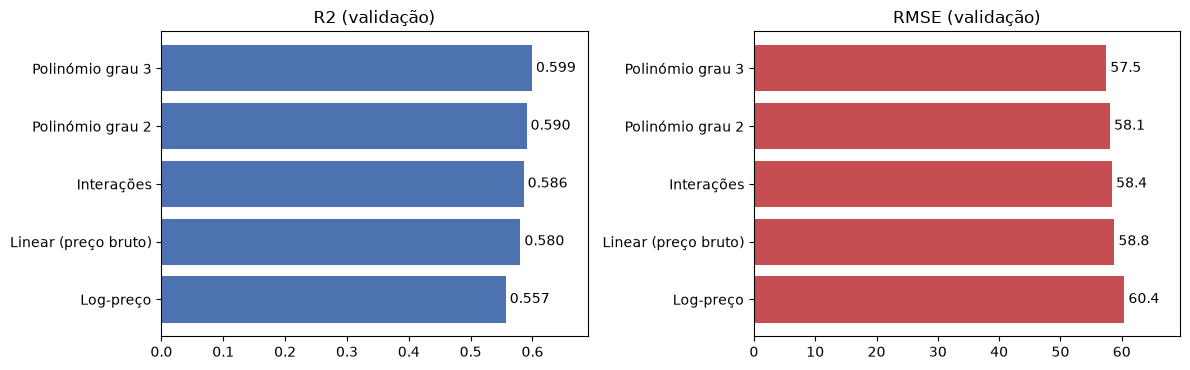

,MAE,RMSE,R2
modelo,,,
Linear (preço bruto),42.768,58.798,0.580
Log-preço,41.301,60.434,0.557
Interações,42.343,58.426,0.586
Polinómio grau 2,42.445,58.093,0.590
Polinómio grau 3,42.076,57.477,0.599


In [42]:
linha_poly = lambda g: df_poly.loc[df_poly["grau"] == g, ["MAE", "RMSE", "R2"]].iloc[0].to_dict()
df_modelos = pd.DataFrame([
    {"modelo": "Linear (preço bruto)", **avaliar(w_base, dados["X_val"], dados["y_val"])},
    {"modelo": "Log-preço", **avaliar_log(w_log, dados["X_val"], dados["y_val"])},
    {"modelo": "Interações", **avaliar(w_int, X_val_int, dados["y_val"])},
    {"modelo": "Polinómio grau 2", **linha_poly(2)},
    {"modelo": "Polinómio grau 3", **linha_poly(3)},
]).set_index("modelo").astype(float)

fig, eixos = plt.subplots(1, 2, figsize=(12, 3.8))
for eixo, metrica, cor in zip(eixos, ["R2", "RMSE"], ["#4C72B0", "#C44E52"]):
    ordenado = df_modelos[metrica].sort_values(ascending=(metrica == "RMSE"))
    eixo.barh(ordenado.index[::-1], ordenado.values[::-1], color=cor)
    for y, v in enumerate(ordenado.values[::-1]):
        eixo.text(v, y, f" {v:.3f}" if metrica == "R2" else f" {v:.1f}", va="center")
    eixo.set_title(metrica + " (validação)")
    eixo.margins(x=0.15)
plt.tight_layout()
plt.show()
df_modelos.round(3)

## 9. Regularização L2 (Ridge)

In [43]:
lambdas = [0, 0.1, 1, 10, 50, 100]
resultados_l2 = []

for l2 in lambdas:
    w, _ = treinar_gradient_descent(dados["X_train"], dados["y_train"], lr=0.05, epochs=500, l2=l2, batch_size=256)
    metrica_val = avaliar(w, dados["X_val"], dados["y_val"])
    resultados_l2.append({"lambda": l2, **metrica_val})

df_l2 = pd.DataFrame(resultados_l2)
df_l2

,lambda,MAE,RMSE,R2
0,0.0,42.768376,58.798367,0.580449
1,0.1,42.769203,58.819829,0.580142
2,1.0,42.969499,59.101653,0.576109
3,10.0,44.071181,60.424705,0.556918
4,50.0,46.868231,63.303809,0.513689
5,100.0,49.365802,65.590050,0.477928


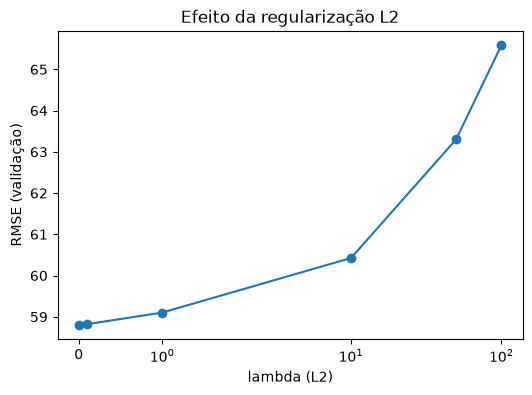

Melhor lambda: 0.0


In [44]:
plt.figure(figsize=(6, 4))
plt.plot(df_l2["lambda"], df_l2["RMSE"], marker="o")
plt.xlabel("lambda (L2)")
plt.ylabel("RMSE (validação)")
plt.title("Efeito da regularização L2")
plt.xscale("symlog")
plt.show()

melhor_lambda = df_l2.loc[df_l2["RMSE"].idxmin(), "lambda"]
print("Melhor lambda:", melhor_lambda)

### Discussão

- **Resultado:** o R² desce de **0,580** (λ=0) para 0,576 (λ=1), 0,557 (λ=10), 0,514 (λ=50) e **0,478** (λ=100); o RMSE sobe de 58,8 para 65,6 €.
- **Melhor λ=0:** sem sobreajuste (treino≈validação), a penalização só reduz os coeficientes e a capacidade explicativa.
- **Porquê:** 15846 observações para apenas 43 variáveis.
- **Valor metodológico:** a extensão L2 ao gradient descent está implementada e testada, mesmo sem benefício neste caso.

## 10. K-fold cross-validation (implementado à mão)

In [45]:
def k_fold_indices(n, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n)
    tamanhos_fold = [n // k + (1 if i < n % k else 0) for i in range(k)]
    folds, inicio = [], 0
    for tam in tamanhos_fold:
        folds.append(indices[inicio:inicio + tam])
        inicio += tam
    return folds

def k_fold_cv(X, y, k=5, lr=0.05, epochs=300, l2=0.0, batch_size=256, seed=SEED):
    n = len(y)
    folds = k_fold_indices(n, k, seed)
    metricas = []
    for i in range(k):
        idx_val = folds[i]
        idx_train = np.concatenate([folds[j] for j in range(k) if j != i])
        w, _ = treinar_gradient_descent(X[idx_train], y[idx_train], lr=lr, epochs=epochs, l2=l2, batch_size=batch_size, seed=seed)
        metricas.append(avaliar(w, X[idx_val], y[idx_val]))
    return pd.DataFrame(metricas)

df_kfold = k_fold_cv(dados["X_train"], dados["y_train"], k=5, l2=melhor_lambda)
print(df_kfold)
print("\nMedia:", df_kfold.mean().to_dict())
print("Desvio-padrao:", df_kfold.std().to_dict())

         MAE       RMSE        R2
0  42.318220  58.109359  0.594465
1  41.820425  56.938524  0.608065
2  41.279004  56.226576  0.609137
3  41.616476  56.534592  0.594680
4  42.095176  56.950612  0.601635

Media: {'MAE': 41.825860079287466, 'RMSE': 56.95193271626796, 'R2': 0.6015963746836055}
Desvio-padrao: {'MAE': 0.40554657840375474, 'RMSE': 0.7141660602586015, 'R2': 0.007024941931413173}


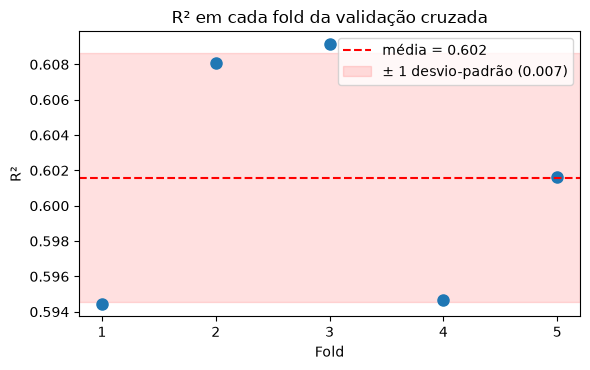

In [46]:
folds = np.arange(1, len(df_kfold) + 1)
media, desvio = df_kfold["R2"].mean(), df_kfold["R2"].std()
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(folds, df_kfold["R2"], "o", markersize=8)
ax.axhline(media, color="red", linestyle="--", label=f"média = {media:.3f}")
ax.axhspan(media - desvio, media + desvio, color="red", alpha=0.12, label=f"± 1 desvio-padrão ({desvio:.3f})")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("R²")
ax.set_title("R² em cada fold da validação cruzada")
ax.legend()
plt.tight_layout()
plt.show()

### Discussão

- **Resultado:** R² médio **0,602 ± 0,007** (folds entre 0,594 e 0,609); RMSE **57,0 ± 0,71 €**.
- **Estabilidade:** o desempenho não depende da partição utilizada.
- **Nota:** o R²=0,580 da validação única fica abaixo dos folds, o que sugere uma partição um pouco mais difícil. A partição afeta a segunda casa decimal.

## 11. Modelo final e análise de resíduos

Os diagnósticos do modelo final (resíduos, real contra previsto e erro por grupo) usam o conjunto de teste, porque o modelo já está escolhido e a validação serviu para o escolher.

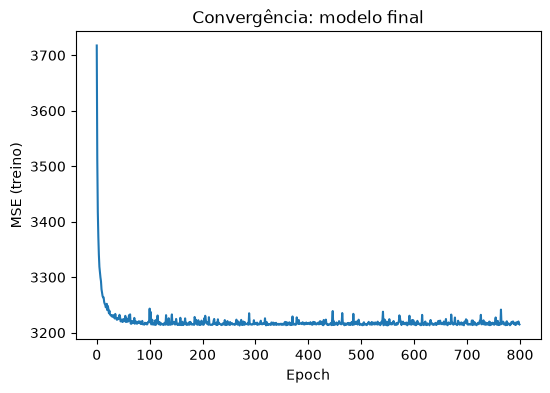

Treino: {'MAE': np.float64(41.73767620864615), 'RMSE': np.float64(56.700386937687625), 'R2': np.float64(0.6052106029100763)}
Val:    {'MAE': np.float64(42.81491951855417), 'RMSE': np.float64(58.778513293299774), 'R2': np.float64(0.5807318303864463)}
Teste:  {'MAE': np.float64(41.50659641199774), 'RMSE': np.float64(56.13511792309425), 'R2': np.float64(0.6114498484089099)}


In [47]:
w_final, custo_final = treinar_gradient_descent(
    dados["X_train"], dados["y_train"], lr=0.05, epochs=800, l2=melhor_lambda, batch_size=256
)

plt.figure(figsize=(6, 4))
plt.plot(custo_final)
plt.xlabel("Epoch")
plt.ylabel("MSE (treino)")
plt.title("Convergência: modelo final")
plt.show()

print("Treino:", avaliar(w_final, dados["X_train"], dados["y_train"]))
print("Val:   ", avaliar(w_final, dados["X_val"], dados["y_val"]))
print("Teste: ", avaliar(w_final, dados["X_test"], dados["y_test"]))

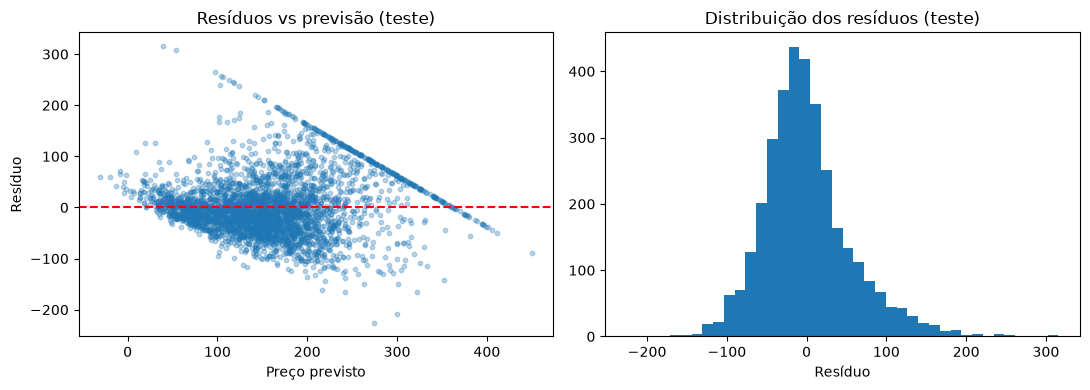

In [48]:
y_pred_teste = prever(adicionar_bias(dados["X_test"]), w_final)
residuos_teste = dados["y_test"] - y_pred_teste

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred_teste, residuos_teste, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Preço previsto")
axes[0].set_ylabel("Resíduo")
axes[0].set_title("Resíduos vs previsão (teste)")

axes[1].hist(residuos_teste, bins=40)
axes[1].set_xlabel("Resíduo")
axes[1].set_title("Distribuição dos resíduos (teste)")
plt.tight_layout()
plt.show()

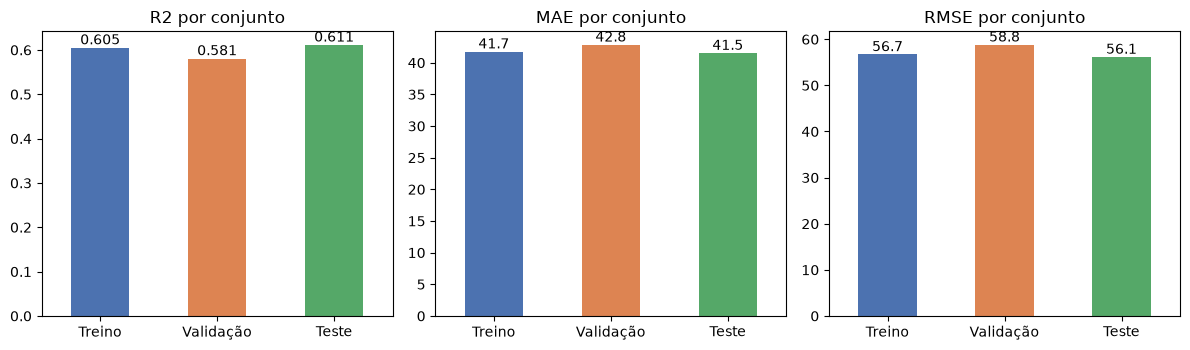

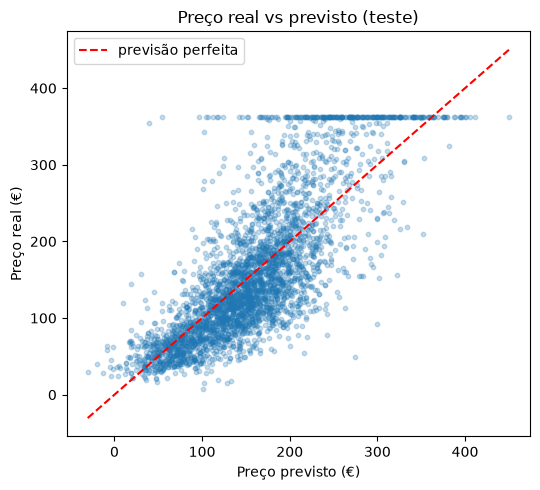

In [49]:
metricas_split = pd.DataFrame({
    "Treino": avaliar(w_final, dados["X_train"], dados["y_train"]),
    "Validação": avaliar(w_final, dados["X_val"], dados["y_val"]),
    "Teste": avaliar(w_final, dados["X_test"], dados["y_test"]),
}).T.astype(float)

fig, eixos = plt.subplots(1, 3, figsize=(12, 3.6))
for eixo, metrica in zip(eixos, ["R2", "MAE", "RMSE"]):
    metricas_split[metrica].plot(kind="bar", ax=eixo, rot=0, color=["#4C72B0", "#DD8452", "#55A868"])
    eixo.bar_label(eixo.containers[0], fmt="%.3f" if metrica == "R2" else "%.1f")
    eixo.set_title(metrica + " por conjunto")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y_pred_teste, dados["y_test"], alpha=0.25, s=10)
limites = [min(y_pred_teste.min(), dados["y_test"].min()), max(y_pred_teste.max(), dados["y_test"].max())]
ax.plot(limites, limites, "r--", label="previsão perfeita")
ax.set_xlabel("Preço previsto (€)")
ax.set_ylabel("Preço real (€)")
ax.set_title("Preço real vs previsto (teste)")
ax.legend()
plt.tight_layout()
plt.show()

### Discussão

- **Resultado:** R² **0,605** (treino), **0,581** (validação) e **0,611** (teste); no teste, MAE=**41,5 €** e RMSE=**56,1 €**. Convém reportar o intervalo **≈0,58 a 0,61**.
- **Convergência:** o MSE estabiliza (≈3200) ao fim de cerca de 50 épocas, com pequenas oscilações devidas aos mini-batches.
- **Resíduos (teste):**
  - **Reta diagonal:** anúncios cujo preço foi limitado pela winsorização (≈362 €); o resíduo é cerca de 362 menos o preço previsto. É um artefacto do tratamento, não do modelo.
  - **Heterocedasticidade:** maior dispersão nas previsões intermédias e altas (≈100 a 300 €) do que nas baixas.
  - **Assimetria:** histograma unimodal, com o pico ligeiramente abaixo de zero e cauda direita mais longa (até ≈310 contra ≈-230), ou seja, o modelo tende a subestimar os alojamentos caros.
  - **Previsões negativas:** existem algumas (mínimo ≈-30 €), porque o modelo linear não impõe positividade.
- **Consequência:** a capacidade preditiva mantém-se, mas inferências sobre os coeficientes (intervalos, testes) não são apresentadas.

## 12. Erro por bairro e por tipo de quarto

Calculado no conjunto de teste.


--- Erro médio absoluto por room_type ---
          grupo  MAE    n
   Private room 29.5  817
Entire home/apt 45.2 2542
     Hotel room 52.8   16
    Shared room 59.3   20

--- Erro médio absoluto por neighbourhood_cleansed ---
                                            grupo  MAE   n
                                   Penha de Frana 28.0  96
                                       So Vicente 33.4 191
                                          Areeiro 33.7  56
                                   Avenidas Novas 34.2 114
                                          Arroios 36.7 298
                                            Other 39.8 871
                                          Estrela 40.4 139
                                         Ericeira 40.5 102
                              Carcavelos e Parede 40.8  61
                                      Misericrdia 42.9 343
                                     Santo Antnio 42.9 202
                                Santa Maria Maior 44.3 490
    

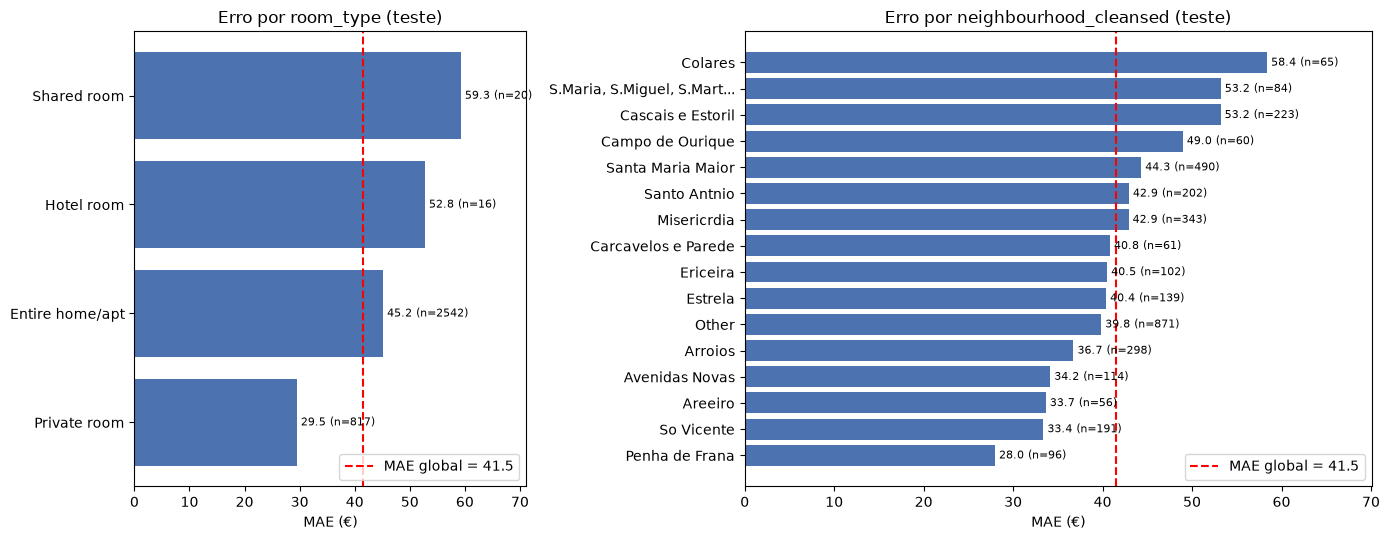

In [50]:
teste_df = dados["test_df_raw"].copy()
teste_df["erro_abs"] = np.abs(residuos_teste)
mae_global = mae(dados["y_test"], y_pred_teste)

abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})
for eixo, prefixo in zip(eixos, ["room_type_", "neighbourhood_cleansed_"]):
    linhas = []
    for c in [c for c in teste_df.columns if c.startswith(prefixo)]:
        mask = teste_df[c] == 1
        if mask.sum() > 0:
            linhas.append({"grupo": c[len(prefixo):], "MAE": teste_df.loc[mask, "erro_abs"].mean(), "n": int(mask.sum())})
    tabela = pd.DataFrame(linhas).sort_values("MAE")
    print(f"\n--- Erro médio absoluto por {prefixo[:-1]} ---")
    print(tabela.round(1).to_string(index=False))

    eixo.barh([abreviar(g) for g in tabela["grupo"]], tabela["MAE"], color="#4C72B0")
    for y, (m, n) in enumerate(zip(tabela["MAE"], tabela["n"])):
        eixo.text(m, y, f" {m:.1f} (n={n})", va="center", fontsize=8)
    eixo.axvline(mae_global, color="red", linestyle="--", label=f"MAE global = {mae_global:.1f}")
    eixo.set_xlabel("MAE (€)")
    eixo.set_title(f"Erro por {prefixo[:-1]} (teste)")
    eixo.margins(x=0.2)
    eixo.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Discussão

- **Por tipo de quarto:** o MAE é mais baixo em `Private room` (**29,5 €**, n=817) e mais alto em `Entire home/apt` (**45,2 €**, n=2542) entre os grupos com amostra relevante. `Shared room` (59,3 €) e `Hotel room` (52,8 €) têm só 20 e 16 observações: o valor de `Shared room` era 46,0 € na validação, o que ilustra a instabilidade com amostras pequenas.
- **Por bairro:** melhores Penha de França (**28,0**), São Vicente (**33,4**) e Areeiro (**33,7**); piores Colares (**58,4**), Cascais e Estoril (**53,2**) e a zona de Sintra (**53,2**).
- **Leitura:** o MAE em euros acompanha o nível e a dispersão dos preços de cada grupo. Campo de Ourique (49,0 €, n=60) tem o quarto erro mais alto, compatível com a forte dispersão de preços da análise exploratória (média de 418 € contra mediana de 124 €). Um erro relativo seria mais comparável, mas não foi calculado.
- **Zonas de maior erro:** Colares, Cascais e Estoril e Sintra são as que mais falham, pelo que o bairro isolado não parece captar a heterogeneidade interna destas zonas.

## 13. Tabela de coeficientes

In [51]:
coef_df = pd.DataFrame({
    "feature": ["bias"] + dados["feature_cols"],
    "coeficiente": w_final,
}).sort_values("coeficiente", key=abs, ascending=False)

coef_df

,feature,coeficiente
0,bias,104.393323
14,room_type_Hotel room,70.380160
13,room_type_Entire home/apt,54.139646
27,property_type_Room in hotel,50.238634
16,room_type_Shared room,-41.874837
1,accommodates,38.954889
33,neighbourhood_cleansed_Cascais e Estoril,36.127035
21,property_type_Entire villa,30.603268
41,neighbourhood_cleansed_Santa Maria Maior,26.467722
15,room_type_Private room,21.748353


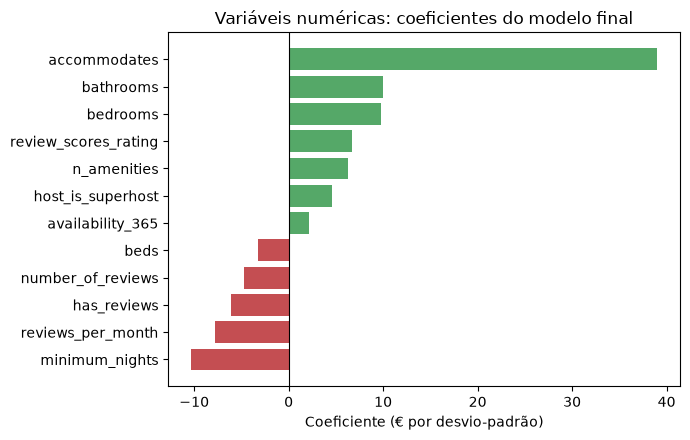

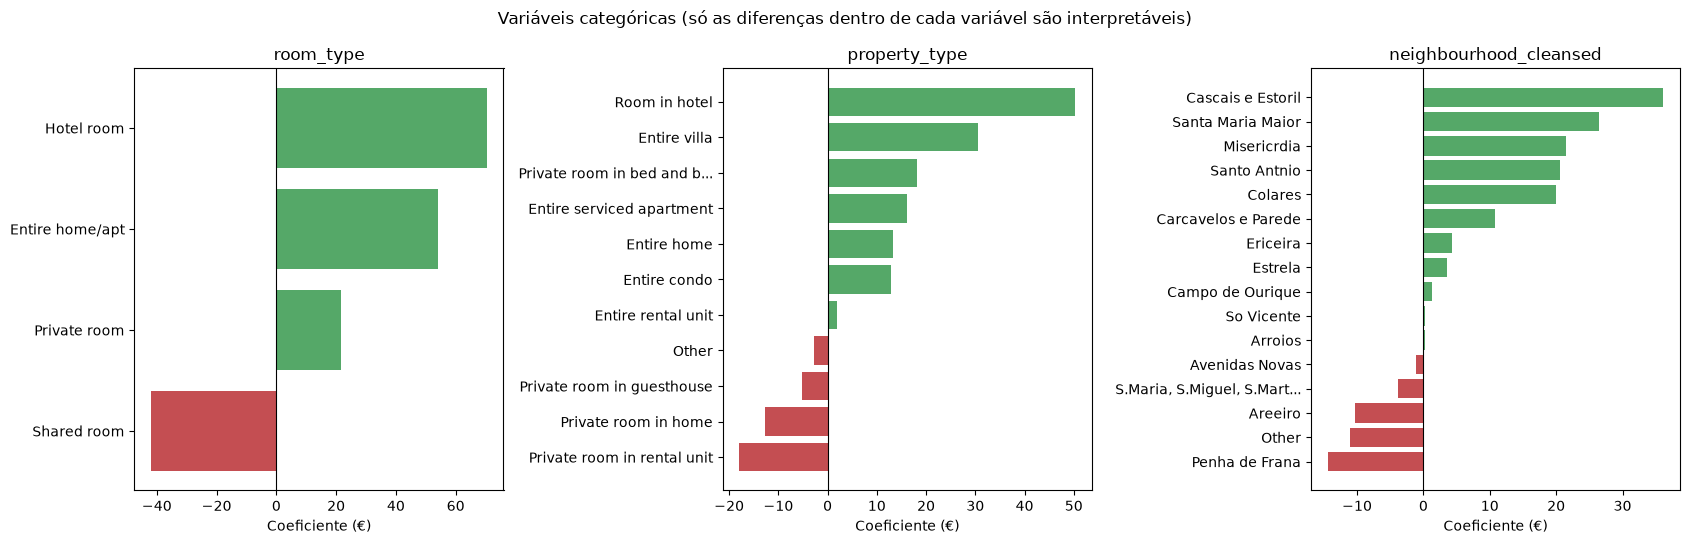

In [52]:
coef = pd.Series(w_final[1:], index=dados["feature_cols"])
prefixos = ["room_type_", "property_type_", "neighbourhood_cleansed_"]
numericas = [c for c in coef.index if not c.startswith(tuple(prefixos))]
abreviar = lambda s: s if len(s) <= 28 else s[:25] + "..."
cor_sinal = lambda s: np.where(s.values > 0, "#55A868", "#C44E52")

ordenado = coef[numericas].sort_values()
plt.figure(figsize=(7, 4.5))
plt.barh(ordenado.index, ordenado.values, color=cor_sinal(ordenado))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (€ por desvio-padrão)")
plt.title("Variáveis numéricas: coeficientes do modelo final")
plt.tight_layout()
plt.show()

fig, eixos = plt.subplots(1, 3, figsize=(17, 5.5))
for eixo, prefixo in zip(eixos, prefixos):
    s = coef[[c for c in coef.index if c.startswith(prefixo)]].sort_values()
    eixo.barh([abreviar(c[len(prefixo):]) for c in s.index], s.values, color=cor_sinal(s))
    eixo.axvline(0, color="black", linewidth=0.8)
    eixo.set_title(prefixo[:-1])
    eixo.set_xlabel("Coeficiente (€)")
fig.suptitle("Variáveis categóricas (só as diferenças dentro de cada variável são interpretáveis)")
plt.tight_layout()
plt.show()

### Discussão

- **Como ler os coeficientes:**
  - **Numéricas** (padronizadas): € por desvio-padrão, comparáveis entre si.
  - **Categóricas** (one-hot): € associados à categoria. Só as **diferenças dentro da mesma variável** são interpretáveis, porque a decomposição face ao termo constante (104,4 €) não é única.
- **Numéricas:** `accommodates` domina (**+39,0**), seguido de `minimum_nights` (-10,3), `bathrooms` (+10,0) e `bedrooms` (+9,8).
  - `minimum_nights` negativo é compatível com arrendamentos de longa duração, mais baratos por noite.
  - `beds` (-3,2) contraria a expectativa: é um efeito parcial, afetado por colinearidade com as outras variáveis de dimensão.
- **Tipo de quarto:** `Hotel room` (70,4) > `Entire home/apt` (54,1) > `Private room` (21,7) > `Shared room` (-41,9). Alojamento inteiro ≈ **+32 €** face a quarto privado, e este ≈ **+64 €** face a partilhado (`Hotel room` com poucas observações).
- **Localização:** prémios em Cascais e Estoril (**+36,1**), Santa Maria Maior (+26,5), Misericórdia (+21,5) e Santo António (+20,6); negativos em Penha de França (-14,4), `Other` (-11,0) e Areeiro (-10,3). Campo de Ourique fica perto de zero (+1,3), apesar da média exploratória de 418 € (inflacionada por poucos anúncios de luxo; mediana de 124 €).
- **Reputação:** `review_scores_rating` (+6,7), `n_amenities` (+6,3) e `host_is_superhost` (+4,6) têm o sinal esperado. `has_reviews` (-6,1), `reviews_per_month` (-7,8) e `number_of_reviews` (-4,8) são negativos: hipótese de que alojamentos mais baratos têm maior rotação de hóspedes, não confirmável com os dados disponíveis.